<a href="https://colab.research.google.com/github/sandesh-kumar25/Python_Workshop/blob/main/rmtw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install transformers datasets accelerate scikit-learn wordcloud seaborn -q

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
    )

import torch
print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from google.colab import files

uploaded = files.upload()

Saving 4.18.csv to 4.18.csv


In [6]:
import pandas as pd

df = pd.read_csv("4.18.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1558, 5)


In [7]:
df.head()
df.info()
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            1558 non-null   object
 1   Link             1558 non-null   object
 2   Abstract         1558 non-null   object
 3   Author Keywords  1503 non-null   object
 4   Index Keywords   1546 non-null   object
dtypes: object(5)
memory usage: 61.0+ KB
Number of rows: 1558
Number of columns: 5

Columns:
['Title', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords']


Missing values:
Title               0
Link                0
Abstract            0
Author Keywords    55
Index Keywords     12
dtype: int64


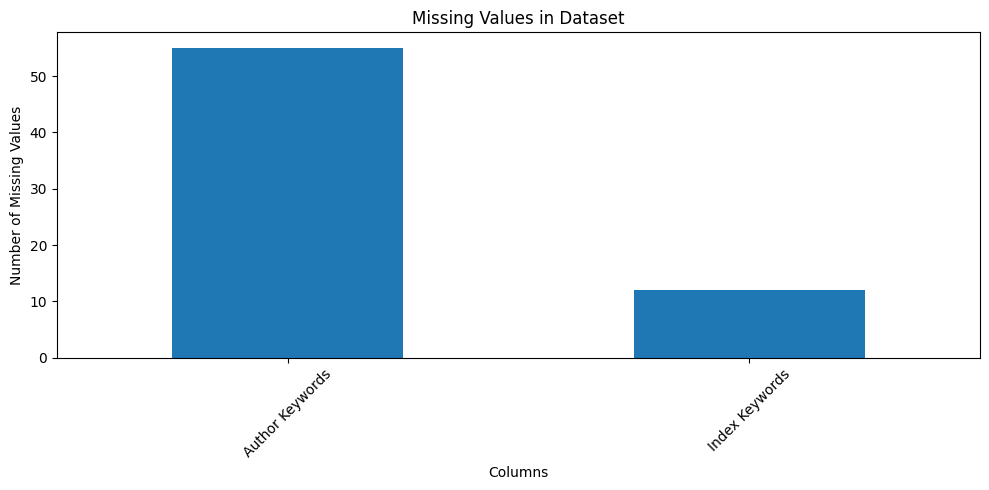

In [8]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)
plt.figure(figsize=(10, 5))

missing[missing > 0].plot(kind="bar")

plt.title("Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df["Title"] = df["Title"].fillna("")
df["Abstract"] = df["Abstract"].fillna("")
df["Author Keywords"] = df["Author Keywords"].fillna("")
df["Index Keywords"] = df["Index Keywords"].fillna("")
df["Link"] = df["Link"].fillna("")
print(df.isnull().sum())

Title              0
Link               0
Abstract           0
Author Keywords    0
Index Keywords     0
dtype: int64


Year
2000.0      2
2001.0      2
2002.0      4
2003.0      2
2004.0     14
2005.0      1
2013.0     54
2014.0      2
2016.0      1
2017.0      1
2019.0     20
2020.0    111
2021.0    112
2022.0    162
2023.0    151
2024.0    140
2025.0    311
2026.0    258
2027.0      1
Name: count, dtype: int64


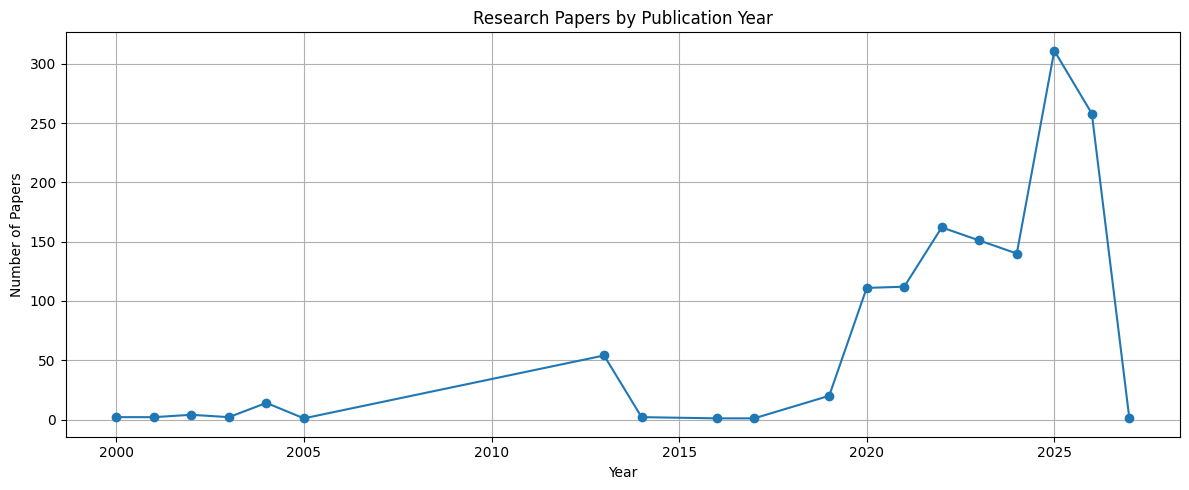

In [10]:
df["Year"] = df["Abstract"].str.extract(r'©\s*(20\d{2})')[0]

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

print(df["Year"].value_counts().sort_index())
year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))

year_counts.plot(kind="line", marker="o")

plt.title("Research Papers by Publication Year")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.grid(True)
plt.tight_layout()
plt.show()

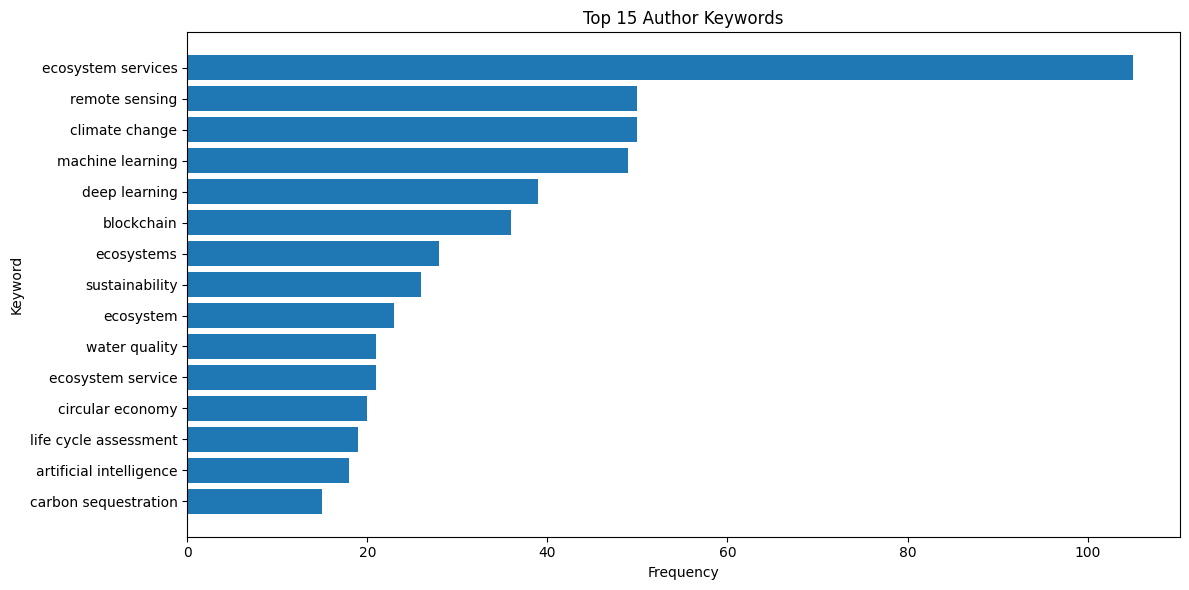

In [11]:
author_keywords = []

for keywords in df["Author Keywords"]:
    if keywords:
            words = keywords.split(";")
            author_keywords.extend([word.strip().lower() for word in words])
author_keyword_counts = Counter(author_keywords)

top_author_keywords = author_keyword_counts.most_common(15)

top_author_keywords

keywords_df = pd.DataFrame(
      top_author_keywords,
      columns=["Keyword", "Count"]
     )

plt.figure(figsize=(12, 6))

plt.barh(
    keywords_df["Keyword"][::-1],
    keywords_df["Count"][::-1]
    )

plt.title("Top 15 Author Keywords")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()


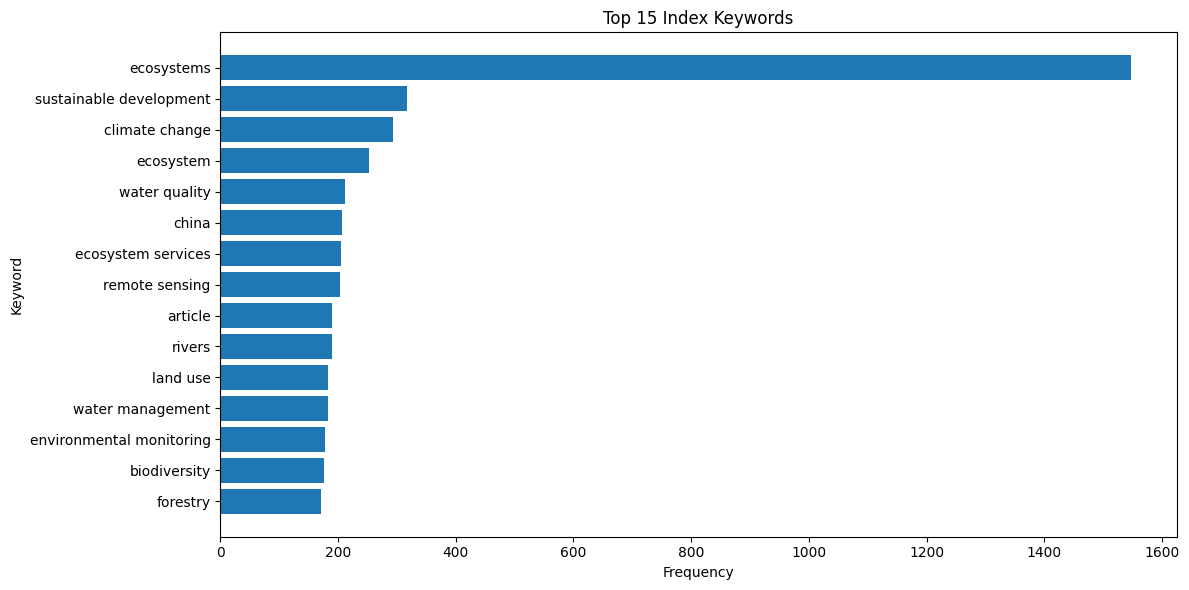

In [12]:
index_keywords = []

for keywords in df["Index Keywords"]:
    if keywords:
            words = keywords.split(";")
            index_keywords.extend([word.strip().lower() for word in words])
index_keyword_counts = Counter(index_keywords)

top_index_keywords = index_keyword_counts.most_common(15)

top_index_keywords
index_df = pd.DataFrame(
      top_index_keywords,
      columns=["Keyword", "Count"]
          )

plt.figure(figsize=(12, 6))

plt.barh(
    index_df["Keyword"][::-1],
    index_df["Count"][::-1]
    )

plt.title("Top 15 Index Keywords")
plt.xlabel("Frequency")
plt.ylabel("Keyword")

plt.tight_layout()
plt.show()


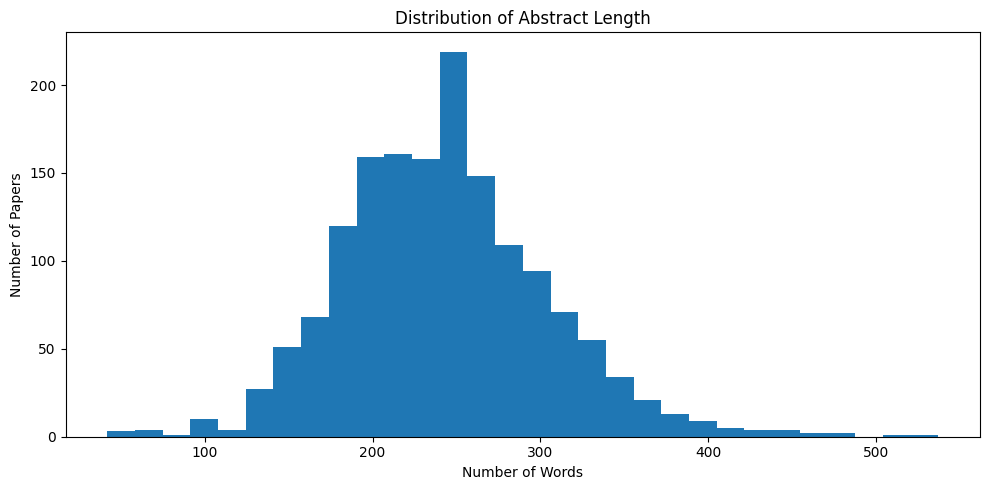

In [13]:
df["Abstract_Length"] = df["Abstract"].apply(
      lambda x: len(x.split())
      )
plt.figure(figsize=(10, 5))

plt.hist(
    df["Abstract_Length"],
    bins=30
    )

plt.title("Distribution of Abstract Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

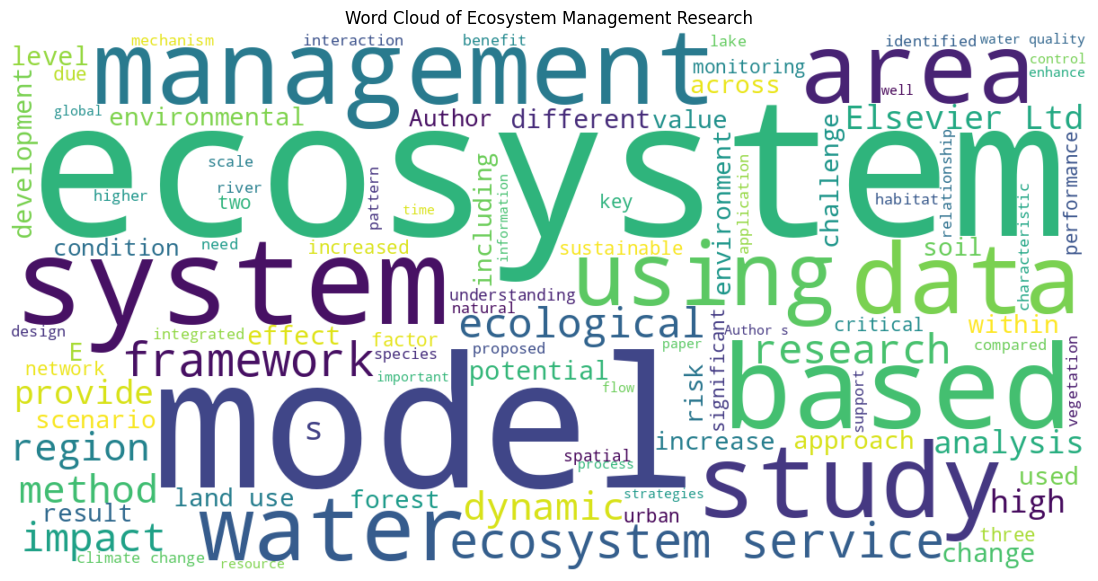

In [14]:
all_abstracts = " ".join(df["Abstract"].tolist())
text = re.sub(r"http\S+|www\S+", "", all_abstracts)
text = re.sub(r"[^a-zA-Z\s]", " ", text)
text = re.sub(r"\s+", " ", text)
wordcloud = WordCloud(
      width=1200,
      height=600,
      background_color="white",
      max_words=100
      ).generate(text)

plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of Ecosystem Management Research")

plt.show()


In [15]:
df["text"] = (
      df["Title"].fillna("") + ". " +
      df["Abstract"].fillna("")
          )

df[["Title", "Abstract", "text"]].head()

,Title,Abstract,text
0,Chronic C-S-Fe defense dominance over nutrient...,Constructed wetlands (CWs) face intensifying t...,Chronic C-S-Fe defense dominance over nutrient...
1,Synergistic multi-site engineering of bound ex...,Efficient near-infrared (NIR) emission in lead...,Synergistic multi-site engineering of bound ex...
2,The Fading Gulf: Morphological Transformations...,This study investigates dynamic morphological ...,The Fading Gulf: Morphological Transformations...
3,HyWaThy: Hybrid modeling of nearshore Waves wi...,Coastal areas such as sandy beaches are highly...,HyWaThy: Hybrid modeling of nearshore Waves wi...
4,A Multifactor Harmonized Vegetation Index Comp...,ccurate monitoring of vegetation dynamics in o...,A Multifactor Harmonized Vegetation Index Comp...


In [16]:
def assign_category(row):
    keywords = (
        str(row["Author Keywords"]) + " " +
        str(row["Index Keywords"])
    ).lower()

    if re.search(
        r"ecosystem services?|ecosystem service",
        keywords
    ):
        return "Ecosystem Services"
    elif re.search(
        r"climate change|global warming|climate variability",
        keywords
    ):
        return "Climate Change"
    elif re.search(
        r"biodiversity|species diversity|species richness",
        keywords
    ):
        return "Biodiversity"
    elif re.search(
        r"wetland|river|watershed|water quality|aquatic|freshwater|lake",
        keywords
    ):
        return "Water & Wetlands"
    elif re.search(
        r"forest|forestry|woodland",
        keywords
    ):
        return "Forest Ecosystems"
    elif re.search(
        r"agricultur|cropland|farmland|land use|soil|agroecosystem",
        keywords
    ):
        return "Agriculture & Land"
    elif re.search(
        r"pollution|contamin|wastewater|heavy metal|nanoplastic|environmental management",
        keywords
    ):
        return "Pollution & Environmental Management"
    else:
        return "Other"

Category Distribution:
Category
Other                                   497
Ecosystem Services                      247
Water & Wetlands                        238
Climate Change                          208
Forest Ecosystems                       108
Agriculture & Land                      100
Biodiversity                             88
Pollution & Environmental Management     72
Name: count, dtype: int64


/tmp/ipykernel_624/2784476268.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


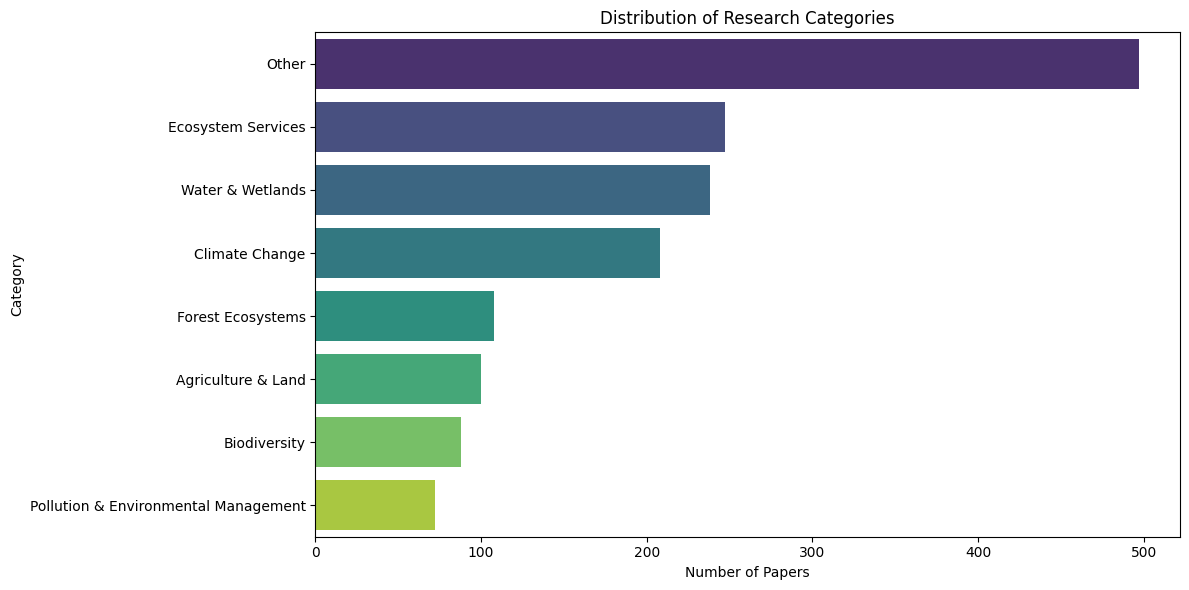

In [17]:
df['Category'] = df.apply(assign_category, axis=1)

category_counts = df['Category'].value_counts()
print("Category Distribution:")
print(category_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Distribution of Research Categories')
plt.xlabel('Number of Papers')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["Category"])

print("Category mapping:")
for i, category in enumerate(label_encoder.classes_):
    print(i, "=", category)

Category mapping:
0 = Agriculture & Land
1 = Biodiversity
2 = Climate Change
3 = Ecosystem Services
4 = Forest Ecosystems
5 = Other
6 = Pollution & Environmental Management
7 = Water & Wetlands


In [19]:
df[["Title", "Abstract", "text", "Category", "label"]].head(5)

,Title,Abstract,text,Category,label
0,Chronic C-S-Fe defense dominance over nutrient...,Constructed wetlands (CWs) face intensifying t...,Chronic C-S-Fe defense dominance over nutrient...,Water & Wetlands,7
1,Synergistic multi-site engineering of bound ex...,Efficient near-infrared (NIR) emission in lead...,Synergistic multi-site engineering of bound ex...,Other,5
2,The Fading Gulf: Morphological Transformations...,This study investigates dynamic morphological ...,The Fading Gulf: Morphological Transformations...,Biodiversity,1
3,HyWaThy: Hybrid modeling of nearshore Waves wi...,Coastal areas such as sandy beaches are highly...,HyWaThy: Hybrid modeling of nearshore Waves wi...,Ecosystem Services,3
4,A Multifactor Harmonized Vegetation Index Comp...,ccurate monitoring of vegetation dynamics in o...,A Multifactor Harmonized Vegetation Index Comp...,Forest Ecosystems,4


In [20]:
df = df[df["text"].str.strip() != ""].copy()

print("Number of papers:", len(df))

Number of papers: 1558


In [21]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 1246
Testing samples: 312


In [22]:
!pip install transformers datasets accelerate -q

In [23]:
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

import torch

print("BERT libraries ready!")

BERT libraries ready!


In [24]:
model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [25]:
train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

In [26]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

In [27]:
class EcosystemDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [28]:
train_dataset = EcosystemDataset(
    train_encodings,
    train_labels
)

test_dataset = EcosystemDataset(
    test_encodings,
    test_labels
)

print("Training dataset:", len(train_dataset))
print("Testing dataset:", len(test_dataset))

Training dataset: 1246
Testing dataset: 312


In [29]:
num_labels = len(label_encoder.classes_)

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

print("Number of classes:", num_labels)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of classes: 8


In [30]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [31]:
training_args = TrainingArguments(
    output_dir="./bert_ecosystem_results",

    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,


    logging_steps=50,

    report_to="none"
)

In [32]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
print("GPU available:", torch.cuda.is_available())